# 1. Imports
Konsolidasi semua library ke dalam satu sel.

In [1]:
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.onnx

import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# 2. Data Preparation
Auto-detect dataset path (Kaggle / Colab / lokal).

In [2]:
import os
import kagglehub

# Check how many images in each folder

# Download latest version
base_dir_downloaded = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
base_dir = os.path.join(base_dir_downloaded, 'The IQ-OTHNCCD lung cancer dataset', 'The IQ-OTHNCCD lung cancer dataset')

print("Path to dataset files:", base_dir)
CLASS_NAMES = ['Bengin cases', 'Malignant cases', 'Normal cases']


for class_name in CLASS_NAMES:
    class_folder = os.path.join(base_dir, class_name);
    files = [f for f in os.listdir(class_folder)]
    print(f"Number of images in {class_name}: {len(files)}")

Path to dataset files: /kaggle/input/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
Number of images in Bengin cases: 120
Number of images in Malignant cases: 561
Number of images in Normal cases: 416


## Visualisasi 1 — Distribusi Dataset per Kelas
Jumlah gambar per kelas sebelum augmentasi.

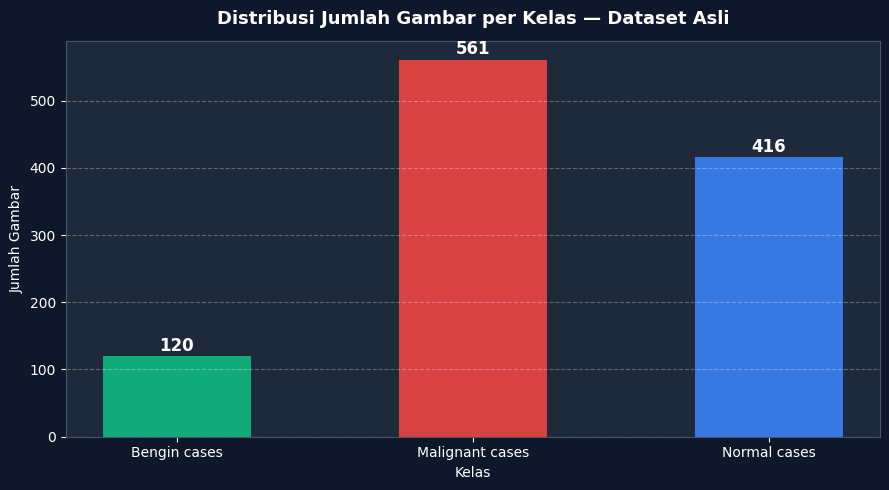

Disimpan: viz_sev_dataset_dist.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

counts = {}
for cls in CLASS_NAMES:
    p = os.path.join(base_dir, cls)
    counts[cls] = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

colors = ["#10b981", "#ef4444", "#3b82f6"]
bars   = ax.bar(CLASS_NAMES, counts.values(), color=colors, alpha=0.9, width=0.5)

for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="white")

ax.set_title("Distribusi Jumlah Gambar per Kelas — Dataset Asli",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_dataset_dist.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_dataset_dist.png")


## Visualisasi 2 — Contoh Gambar CT-Scan per Kelas
3 sampel dari masing-masing kelas dataset IQ-OTH/NCCD.

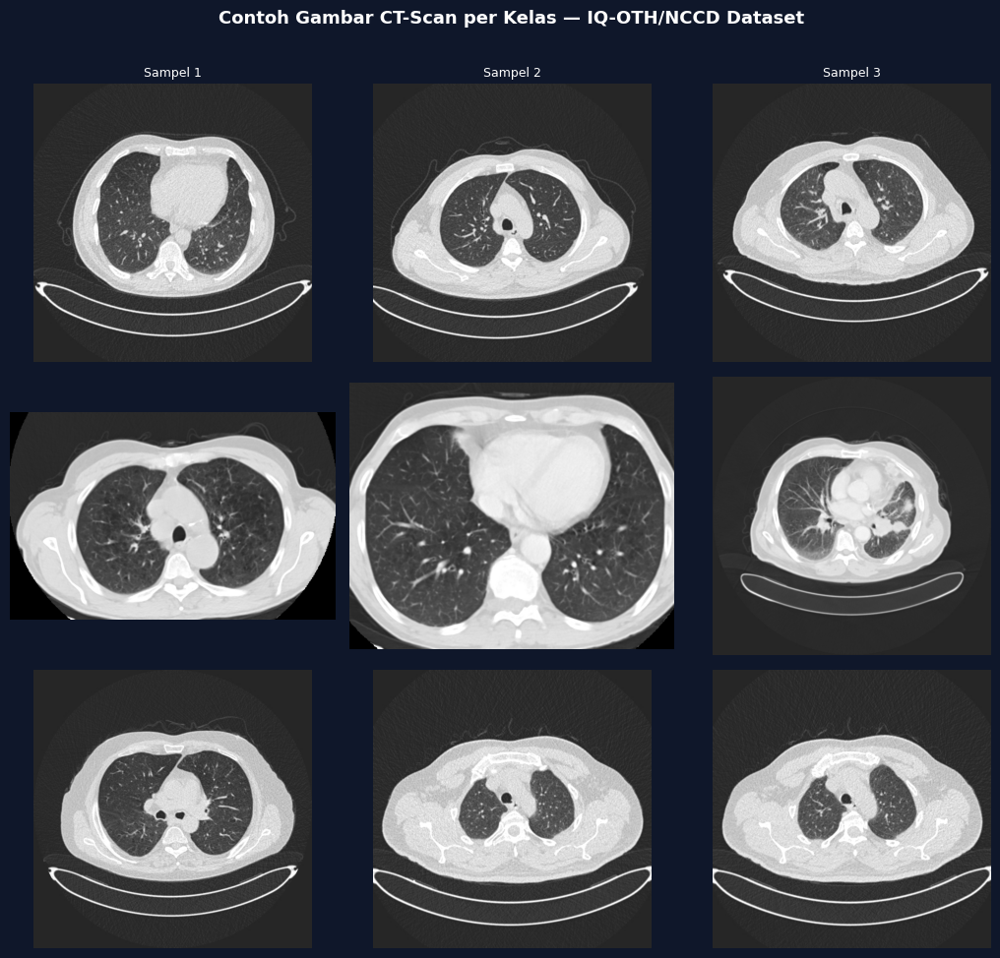

Disimpan: viz_sev_sample_images.png


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import os, random

N = 3
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(len(CLASS_NAMES), N,
                         figsize=(N * 3.5, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Contoh Gambar CT-Scan per Kelas — IQ-OTH/NCCD Dataset",
             fontsize=13, fontweight="bold", color="white", y=1.01)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    samples = random.sample(files, min(N, len(files)))
    for col, fname in enumerate(samples):
        ax = axes[row][col]
        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, color=color,
                          fontweight="bold", rotation=90, labelpad=8)
        if row == 0:
            ax.set_title(f"Sampel {col+1}", fontsize=9, color="white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)

plt.tight_layout()
plt.savefig("viz_sev_sample_images.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_sample_images.png")


## Visualisasi 1 — Distribusi Dataset per Kelas
Jumlah gambar per kelas sebelum augmentasi.

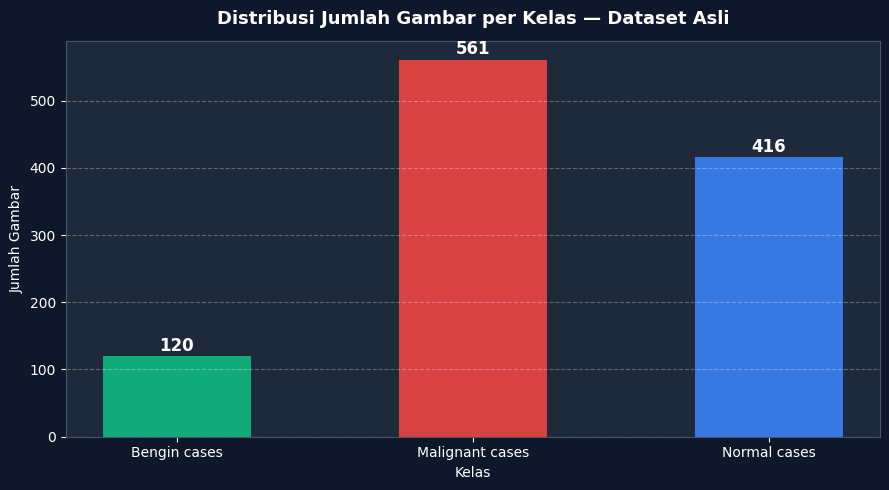

Disimpan: viz_sev_dataset_dist.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

counts = {}
for cls in CLASS_NAMES:
    p = os.path.join(base_dir, cls)
    counts[cls] = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

colors = ["#10b981", "#ef4444", "#3b82f6"]
bars   = ax.bar(CLASS_NAMES, counts.values(), color=colors, alpha=0.9, width=0.5)

for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="white")

ax.set_title("Distribusi Jumlah Gambar per Kelas — Dataset Asli",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_dataset_dist.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_dataset_dist.png")


## Visualisasi 2 — Contoh Gambar CT-Scan per Kelas
3 sampel dari masing-masing kelas dataset IQ-OTH/NCCD.

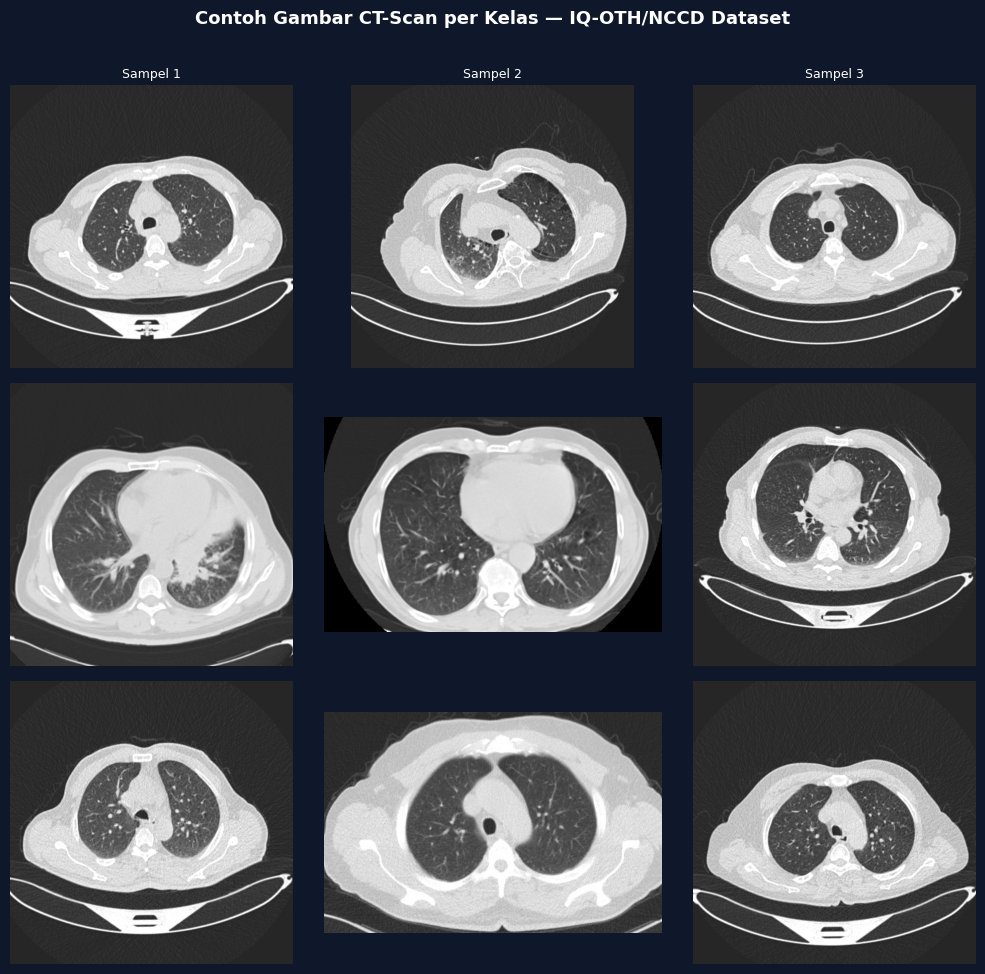

Disimpan: viz_sev_sample_images.png


In [6]:
from PIL import Image
import matplotlib.pyplot as plt
import os, random

N = 3
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(len(CLASS_NAMES), N,
                         figsize=(N * 3.5, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Contoh Gambar CT-Scan per Kelas — IQ-OTH/NCCD Dataset",
             fontsize=13, fontweight="bold", color="white", y=1.01)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    samples = random.sample(files, min(N, len(files)))
    for col, fname in enumerate(samples):
        ax = axes[row][col]
        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, color=color,
                          fontweight="bold", rotation=90, labelpad=8)
        if row == 0:
            ax.set_title(f"Sampel {col+1}", fontsize=9, color="white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)

plt.tight_layout()
plt.savefig("viz_sev_sample_images.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_sample_images.png")


## Visualisasi 1 — Distribusi Dataset per Kelas
Jumlah gambar per kelas sebelum augmentasi.

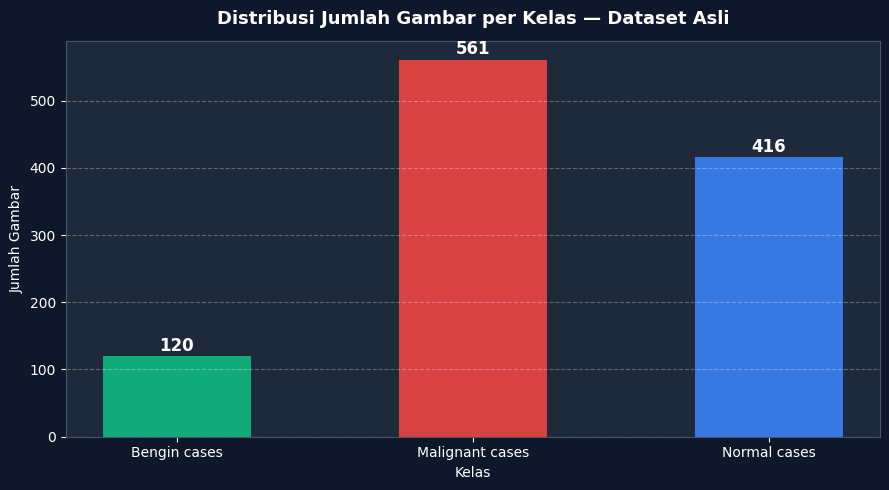

Disimpan: viz_sev_dataset_dist.png


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os

counts = {}
for cls in CLASS_NAMES:
    p = os.path.join(base_dir, cls)
    counts[cls] = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

colors = ["#10b981", "#ef4444", "#3b82f6"]
bars   = ax.bar(CLASS_NAMES, counts.values(), color=colors, alpha=0.9, width=0.5)

for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="white")

ax.set_title("Distribusi Jumlah Gambar per Kelas — Dataset Asli",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_dataset_dist.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_dataset_dist.png")


## Visualisasi 2 — Contoh Gambar CT-Scan per Kelas
3 sampel dari masing-masing kelas dataset IQ-OTH/NCCD.

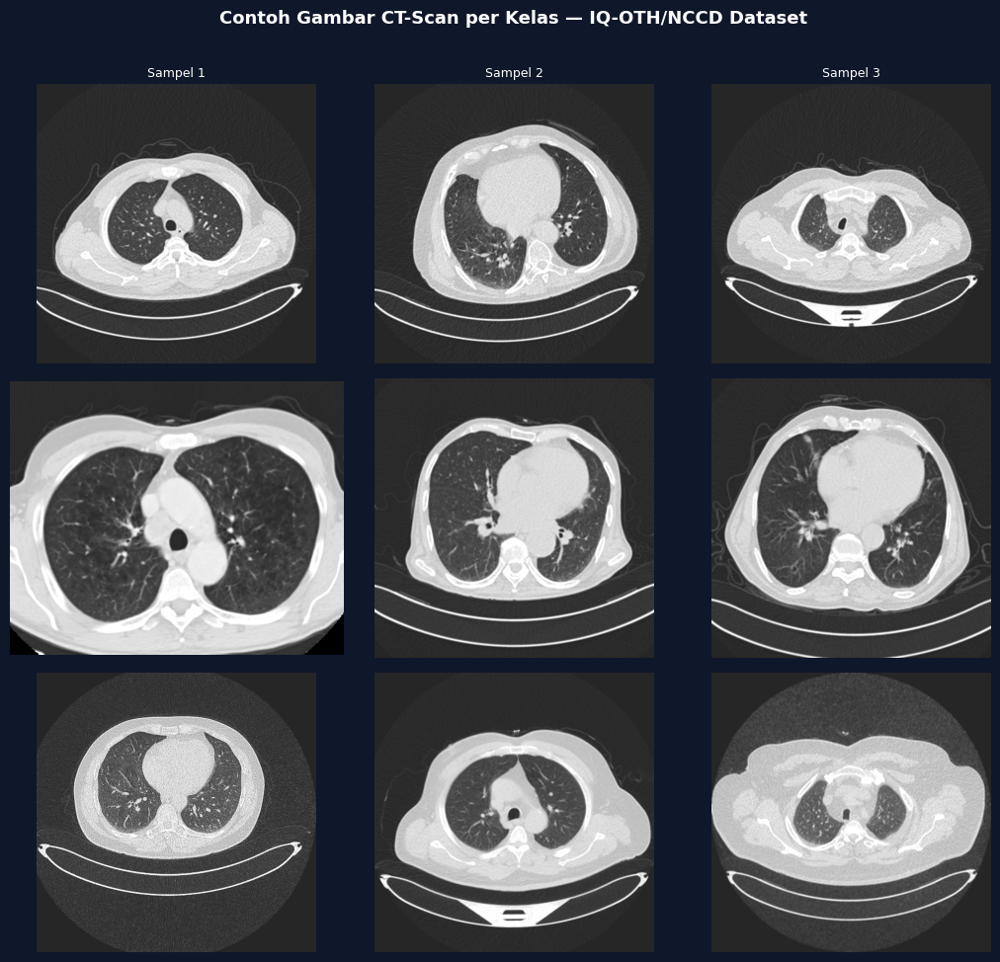

Disimpan: viz_sev_sample_images.png


In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os, random

N = 3
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(len(CLASS_NAMES), N,
                         figsize=(N * 3.5, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Contoh Gambar CT-Scan per Kelas — IQ-OTH/NCCD Dataset",
             fontsize=13, fontweight="bold", color="white", y=1.01)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    samples = random.sample(files, min(N, len(files)))
    for col, fname in enumerate(samples):
        ax = axes[row][col]
        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, color=color,
                          fontweight="bold", rotation=90, labelpad=8)
        if row == 0:
            ax.set_title(f"Sampel {col+1}", fontsize=9, color="white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)

plt.tight_layout()
plt.savefig("viz_sev_sample_images.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_sample_images.png")


## Visualisasi 1 — Distribusi Dataset per Kelas
Jumlah gambar per kelas sebelum augmentasi.

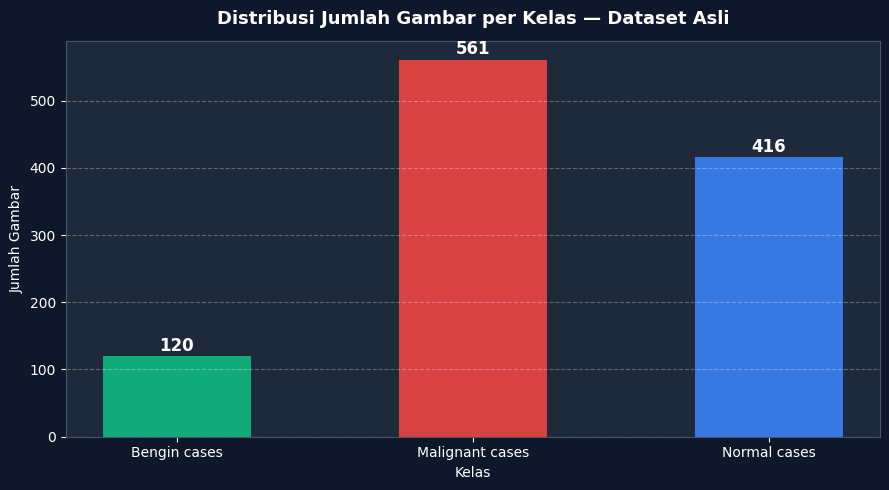

Disimpan: viz_sev_dataset_dist.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os

counts = {}
for cls in CLASS_NAMES:
    p = os.path.join(base_dir, cls)
    counts[cls] = len([f for f in os.listdir(p) if os.path.isfile(os.path.join(p, f))])

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#1e293b")

colors = ["#10b981", "#ef4444", "#3b82f6"]
bars   = ax.bar(CLASS_NAMES, counts.values(), color=colors, alpha=0.9, width=0.5)

for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            str(v), ha="center", va="bottom", fontsize=12,
            fontweight="bold", color="white")

ax.set_title("Distribusi Jumlah Gambar per Kelas — Dataset Asli",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_dataset_dist.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_dataset_dist.png")


## Visualisasi 2 — Contoh Gambar CT-Scan per Kelas
3 sampel dari masing-masing kelas dataset IQ-OTH/NCCD.

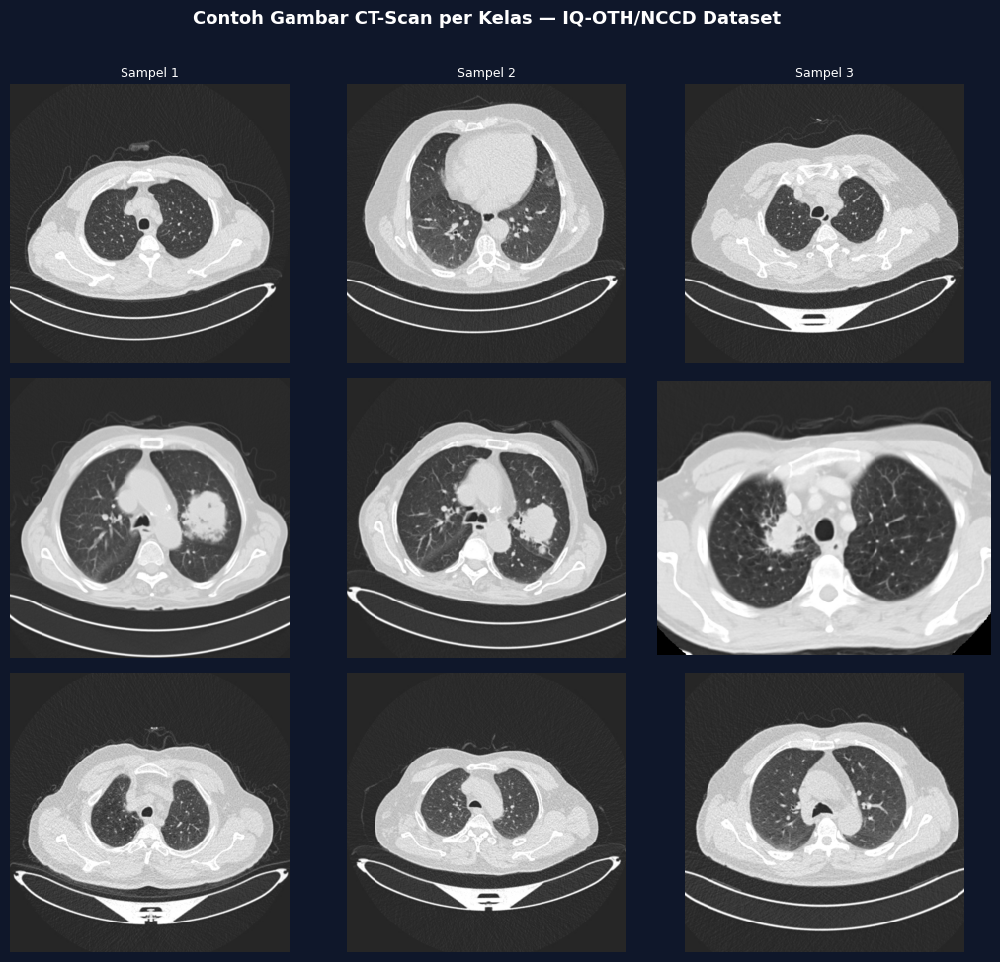

Disimpan: viz_sev_sample_images.png


In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os, random

N = 3
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(len(CLASS_NAMES), N,
                         figsize=(N * 3.5, len(CLASS_NAMES) * 3.2))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Contoh Gambar CT-Scan per Kelas — IQ-OTH/NCCD Dataset",
             fontsize=13, fontweight="bold", color="white", y=1.01)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    samples = random.sample(files, min(N, len(files)))
    for col, fname in enumerate(samples):
        ax = axes[row][col]
        img = Image.open(os.path.join(folder, fname)).convert("RGB")
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_facecolor("#0f172a")
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, color=color,
                          fontweight="bold", rotation=90, labelpad=8)
        if row == 0:
            ax.set_title(f"Sampel {col+1}", fontsize=9, color="white")
        for spine in ax.spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2); spine.set_visible(True)

plt.tight_layout()
plt.savefig("viz_sev_sample_images.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_sample_images.png")


# 3. Data Splitting
Split dataset 80/20 secara fisik **sebelum** augmentasi — mencegah data leakage.

In [11]:
assert 'base_dir' in dir() and base_dir is not None, \
    "ERROR: Jalankan Cell 2 (Data Preparation) terlebih dahulu!"

# Tentukan output dir (Kaggle pakai /kaggle/working, selain itu pakai local)
_working = '/kaggle/working' if os.path.isdir('/kaggle/working') else '.'
TRAIN_DIR = os.path.join(_working, 'dataset', 'train')
VAL_DIR   = os.path.join(_working, 'dataset', 'val')

# Reset direktori
for _d in [TRAIN_DIR, VAL_DIR]:
    if os.path.exists(_d):
        shutil.rmtree(_d)
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(_d, cls), exist_ok=True)

TRAIN_RATIO = 0.8

for cls in CLASS_NAMES:
    src_folder = os.path.join(base_dir, cls)
    files = sorted([f for f in os.listdir(src_folder) if os.path.isfile(os.path.join(src_folder, f))])
    random.shuffle(files)

    split_idx   = int(len(files) * TRAIN_RATIO)
    train_files = files[:split_idx]
    val_files   = files[split_idx:]

    for f in train_files:
        shutil.copy(os.path.join(src_folder, f), os.path.join(TRAIN_DIR, cls, f))
    for f in val_files:
        shutil.copy(os.path.join(src_folder, f), os.path.join(VAL_DIR, cls, f))

    print(f"  {cls}: {len(train_files)} train | {len(val_files)} val")

print(f"\nSplit selesai -> train: {TRAIN_DIR} | val: {VAL_DIR}")

  Bengin cases: 96 train | 24 val
  Malignant cases: 448 train | 113 val
  Normal cases: 332 train | 84 val

Split selesai -> train: /kaggle/working/dataset/train | val: /kaggle/working/dataset/val


## Visualisasi 4 — Distribusi Dataset Setelah Augmentasi
Perbandingan jumlah gambar sebelum dan sesudah proses penyeimbangan kelas.

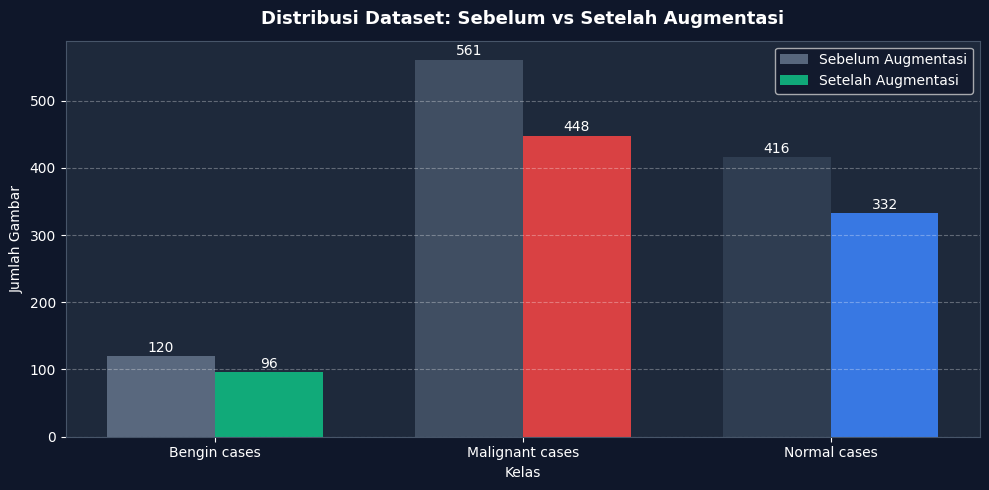

Disimpan: viz_sev_aug_before_after.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

before = {}
after  = {}
for cls in CLASS_NAMES:
    src = os.path.join(base_dir, cls)
    before[cls] = len([f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))])
    dst = os.path.join(TRAIN_DIR, cls)
    after[cls]  = len([f for f in os.listdir(dst) if os.path.isfile(os.path.join(dst, f))])

x = np.arange(len(CLASS_NAMES)); width = 0.35
colors_b = ["#64748b", "#475569", "#334155"]
colors_a = ["#10b981", "#ef4444", "#3b82f6"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#1e293b")

b1 = ax.bar(x - width/2, before.values(), width, label="Sebelum Augmentasi",
            color=colors_b, alpha=0.85)
b2 = ax.bar(x + width/2, after.values(),  width, label="Setelah Augmentasi",
            color=colors_a, alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=10, color="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color="white")
ax.set_title("Distribusi Dataset: Sebelum vs Setelah Augmentasi",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_aug_before_after.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_aug_before_after.png")


## Visualisasi 4 — Distribusi Dataset Setelah Augmentasi
Perbandingan jumlah gambar sebelum dan sesudah proses penyeimbangan kelas.

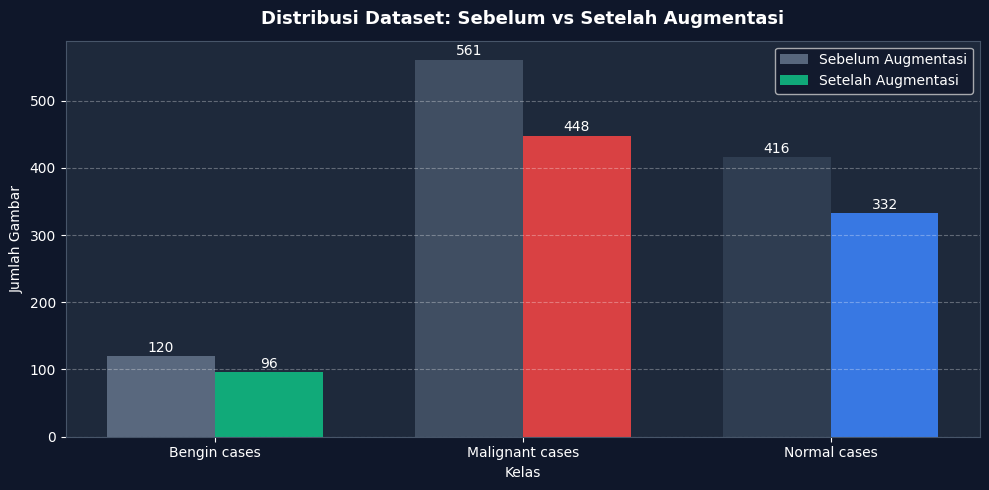

Disimpan: viz_sev_aug_before_after.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os

before = {}
after  = {}
for cls in CLASS_NAMES:
    src = os.path.join(base_dir, cls)
    before[cls] = len([f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))])
    dst = os.path.join(TRAIN_DIR, cls)
    after[cls]  = len([f for f in os.listdir(dst) if os.path.isfile(os.path.join(dst, f))])

x = np.arange(len(CLASS_NAMES)); width = 0.35
colors_b = ["#64748b", "#475569", "#334155"]
colors_a = ["#10b981", "#ef4444", "#3b82f6"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#1e293b")

b1 = ax.bar(x - width/2, before.values(), width, label="Sebelum Augmentasi",
            color=colors_b, alpha=0.85)
b2 = ax.bar(x + width/2, after.values(),  width, label="Setelah Augmentasi",
            color=colors_a, alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=10, color="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color="white")
ax.set_title("Distribusi Dataset: Sebelum vs Setelah Augmentasi",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_aug_before_after.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_aug_before_after.png")


## Visualisasi 4 — Distribusi Dataset Setelah Augmentasi
Perbandingan jumlah gambar sebelum dan sesudah proses penyeimbangan kelas.

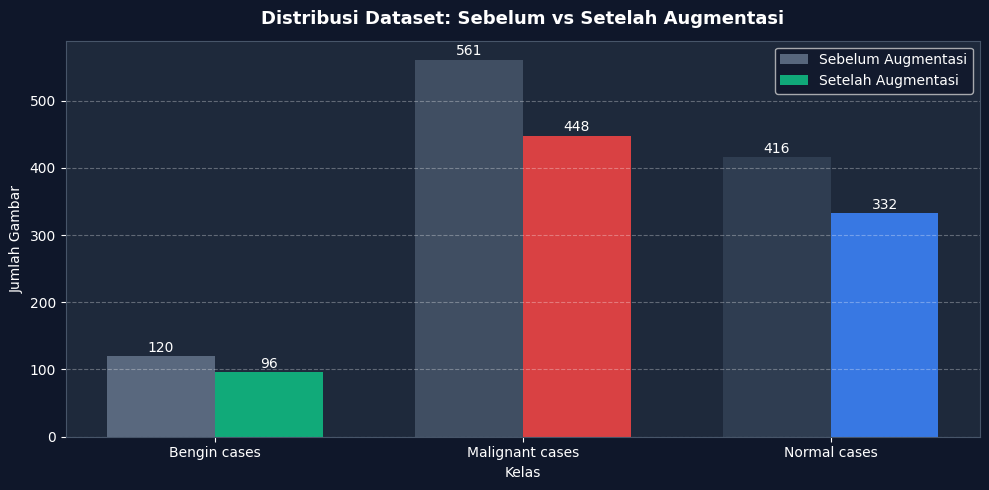

Disimpan: viz_sev_aug_before_after.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

before = {}
after  = {}
for cls in CLASS_NAMES:
    src = os.path.join(base_dir, cls)
    before[cls] = len([f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))])
    dst = os.path.join(TRAIN_DIR, cls)
    after[cls]  = len([f for f in os.listdir(dst) if os.path.isfile(os.path.join(dst, f))])

x = np.arange(len(CLASS_NAMES)); width = 0.35
colors_b = ["#64748b", "#475569", "#334155"]
colors_a = ["#10b981", "#ef4444", "#3b82f6"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#1e293b")

b1 = ax.bar(x - width/2, before.values(), width, label="Sebelum Augmentasi",
            color=colors_b, alpha=0.85)
b2 = ax.bar(x + width/2, after.values(),  width, label="Setelah Augmentasi",
            color=colors_a, alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=10, color="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color="white")
ax.set_title("Distribusi Dataset: Sebelum vs Setelah Augmentasi",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_aug_before_after.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_aug_before_after.png")


## Visualisasi 4 — Distribusi Dataset Setelah Augmentasi
Perbandingan jumlah gambar sebelum dan sesudah proses penyeimbangan kelas.

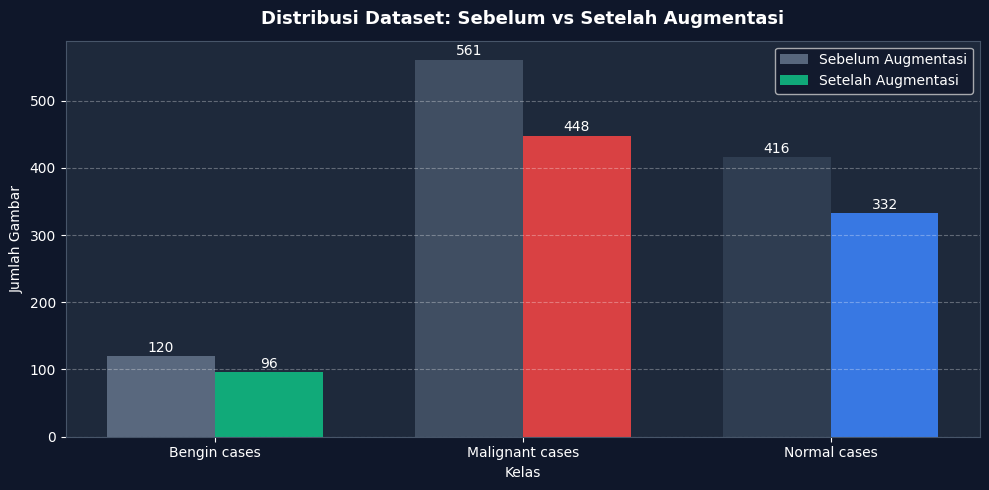

Disimpan: viz_sev_aug_before_after.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import os

before = {}
after  = {}
for cls in CLASS_NAMES:
    src = os.path.join(base_dir, cls)
    before[cls] = len([f for f in os.listdir(src) if os.path.isfile(os.path.join(src, f))])
    dst = os.path.join(TRAIN_DIR, cls)
    after[cls]  = len([f for f in os.listdir(dst) if os.path.isfile(os.path.join(dst, f))])

x = np.arange(len(CLASS_NAMES)); width = 0.35
colors_b = ["#64748b", "#475569", "#334155"]
colors_a = ["#10b981", "#ef4444", "#3b82f6"]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#1e293b")

b1 = ax.bar(x - width/2, before.values(), width, label="Sebelum Augmentasi",
            color=colors_b, alpha=0.85)
b2 = ax.bar(x + width/2, after.values(),  width, label="Setelah Augmentasi",
            color=colors_a, alpha=0.9)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=10, color="white")

ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, color="white")
ax.set_title("Distribusi Dataset: Sebelum vs Setelah Augmentasi",
             fontsize=13, fontweight="bold", color="white", pad=12)
ax.set_xlabel("Kelas", color="white"); ax.set_ylabel("Jumlah Gambar", color="white")
ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.legend(facecolor="#0f172a", labelcolor="white")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="white")
plt.tight_layout()
plt.savefig("viz_sev_aug_before_after.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_aug_before_after.png")


# 4. Data Augmentation (Hanya Data Latih)
Menyeimbangkan tiap kelas sampai `TARGET_COUNT` gambar dengan transformasi acak.

In [16]:
assert 'TRAIN_DIR' in dir(), "ERROR: Jalankan Cell 3 (Data Splitting) terlebih dahulu!"

TARGET_COUNT = 600
IMG_SIZE     = (512, 512)

def get_random_transform():
    transforms_list = [
        lambda img: img.transpose(Image.FLIP_LEFT_RIGHT),
        lambda img: img.transpose(Image.FLIP_TOP_BOTTOM),
        lambda img: img.rotate(random.uniform(-25, 25)),
        lambda img: ImageEnhance.Contrast(img).enhance(random.uniform(1.2, 1.8)),
        lambda img: ImageEnhance.Color(img).enhance(random.uniform(1.2, 2.0)),
        lambda img: ImageEnhance.Sharpness(img).enhance(random.uniform(1.5, 2.5)),
    ]
    return random.choice(transforms_list)

def augment_class(cls, target):
    dst = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(dst) if os.path.isfile(os.path.join(dst, f))]
    needed = target - len(imgs)
    if needed <= 0:
        print(f"  {cls}: cukup ({len(imgs)} gambar), tidak perlu augmentasi")
        return
    print(f"  {cls}: menghasilkan {needed} gambar tambahan...")
    for i in range(needed):
        src_name = random.choice(imgs)
        try:
            with Image.open(os.path.join(dst, src_name)) as img:
                img = img.convert('RGB').resize(IMG_SIZE)
                aug = get_random_transform()(img)
                aug.save(os.path.join(dst, f"aug_{i:05d}_{src_name}"))
        except Exception as e:
            print(f"    Skipped {src_name}: {e}")

for cls in CLASS_NAMES:
    augment_class(cls, TARGET_COUNT)

print("\nAugmentasi selesai!")

  Bengin cases: menghasilkan 504 gambar tambahan...
  Malignant cases: menghasilkan 152 gambar tambahan...
  Normal cases: menghasilkan 268 gambar tambahan...

Augmentasi selesai!


## Visualisasi 3 — Contoh Augmentasi Data
Perbandingan transformasi augmentasi yang diterapkan pada satu gambar sampel per kelas.

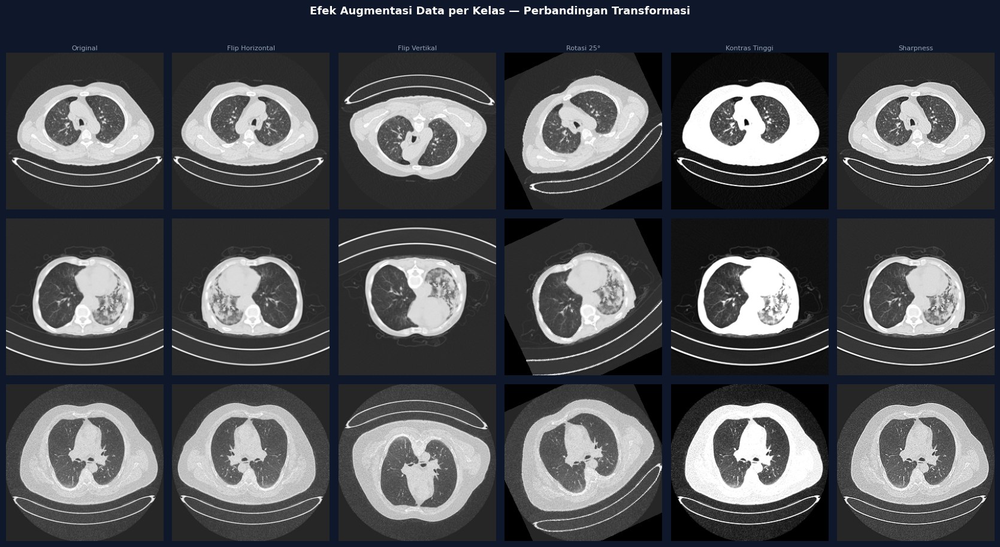

Disimpan: viz_sev_augmentation.png


In [17]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import os, random, copy

def apply_transforms(img):
    return [
        ("Original",       img.copy()),
        ("Flip Horizontal",img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("Flip Vertikal",  img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("Rotasi 25°",     img.rotate(25)),
        ("Kontras Tinggi", ImageEnhance.Contrast(img).enhance(1.6)),
        ("Sharpness",      ImageEnhance.Sharpness(img).enhance(2.0)),
    ]

n_cls = len(CLASS_NAMES)
n_aug = 6
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(n_cls, n_aug, figsize=(n_aug * 2.8, n_cls * 3))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Efek Augmentasi Data per Kelas — Perbandingan Transformasi",
             fontsize=13, fontweight="bold", color="white", y=1.02)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    img_path = os.path.join(folder, random.choice(files))
    img = Image.open(img_path).convert("RGB").resize((256, 256))
    transforms = apply_transforms(img)

    for col, (name, aug_img) in enumerate(transforms):
        ax = axes[row][col]
        ax.imshow(aug_img); ax.axis("off"); ax.set_facecolor("#0f172a")
        if row == 0:
            ax.set_title(name, fontsize=8, color="#94a3b8", pad=3)
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, color=color,
                          fontweight="bold", rotation=90, labelpad=6)

plt.tight_layout()
plt.savefig("viz_sev_augmentation.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_augmentation.png")


## Visualisasi 3 — Contoh Augmentasi Data
Perbandingan transformasi augmentasi yang diterapkan pada satu gambar sampel per kelas.

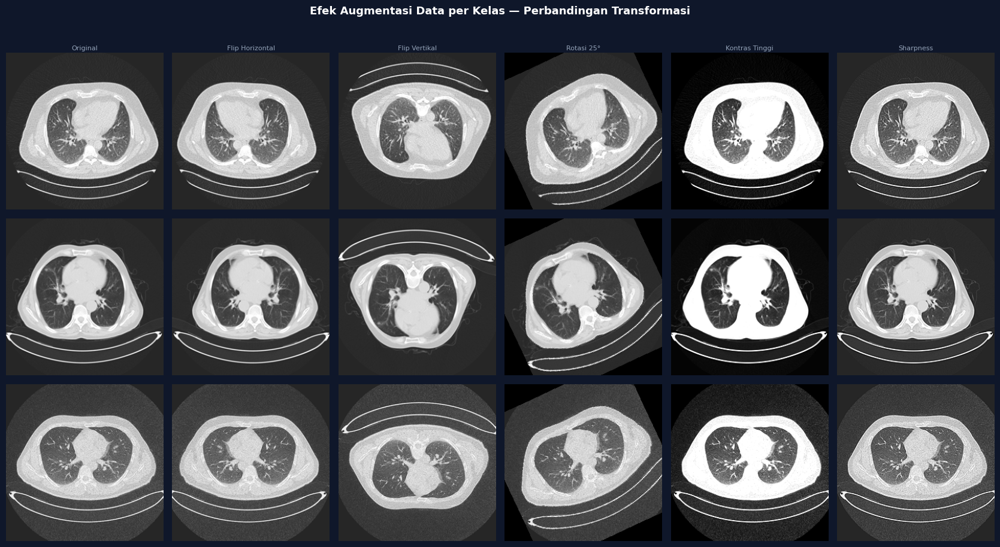

Disimpan: viz_sev_augmentation.png


In [18]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import os, random, copy

def apply_transforms(img):
    return [
        ("Original",       img.copy()),
        ("Flip Horizontal",img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("Flip Vertikal",  img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("Rotasi 25°",     img.rotate(25)),
        ("Kontras Tinggi", ImageEnhance.Contrast(img).enhance(1.6)),
        ("Sharpness",      ImageEnhance.Sharpness(img).enhance(2.0)),
    ]

n_cls = len(CLASS_NAMES)
n_aug = 6
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(n_cls, n_aug, figsize=(n_aug * 2.8, n_cls * 3))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Efek Augmentasi Data per Kelas — Perbandingan Transformasi",
             fontsize=13, fontweight="bold", color="white", y=1.02)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    img_path = os.path.join(folder, random.choice(files))
    img = Image.open(img_path).convert("RGB").resize((256, 256))
    transforms = apply_transforms(img)

    for col, (name, aug_img) in enumerate(transforms):
        ax = axes[row][col]
        ax.imshow(aug_img); ax.axis("off"); ax.set_facecolor("#0f172a")
        if row == 0:
            ax.set_title(name, fontsize=8, color="#94a3b8", pad=3)
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, color=color,
                          fontweight="bold", rotation=90, labelpad=6)

plt.tight_layout()
plt.savefig("viz_sev_augmentation.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_augmentation.png")


## Visualisasi 3 — Contoh Augmentasi Data
Perbandingan transformasi augmentasi yang diterapkan pada satu gambar sampel per kelas.

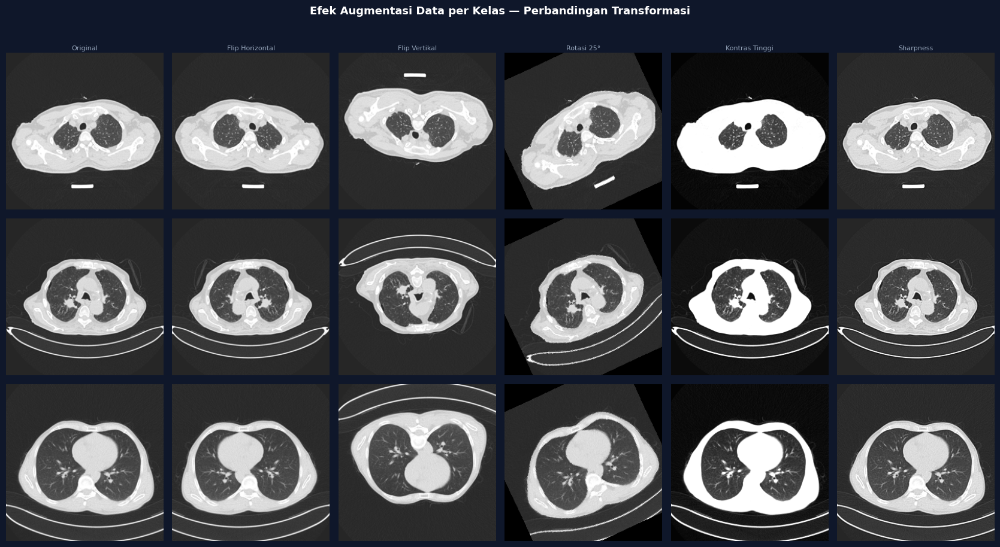

Disimpan: viz_sev_augmentation.png


In [19]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import os, random, copy

def apply_transforms(img):
    return [
        ("Original",       img.copy()),
        ("Flip Horizontal",img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("Flip Vertikal",  img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("Rotasi 25°",     img.rotate(25)),
        ("Kontras Tinggi", ImageEnhance.Contrast(img).enhance(1.6)),
        ("Sharpness",      ImageEnhance.Sharpness(img).enhance(2.0)),
    ]

n_cls = len(CLASS_NAMES)
n_aug = 6
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(n_cls, n_aug, figsize=(n_aug * 2.8, n_cls * 3))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Efek Augmentasi Data per Kelas — Perbandingan Transformasi",
             fontsize=13, fontweight="bold", color="white", y=1.02)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    img_path = os.path.join(folder, random.choice(files))
    img = Image.open(img_path).convert("RGB").resize((256, 256))
    transforms = apply_transforms(img)

    for col, (name, aug_img) in enumerate(transforms):
        ax = axes[row][col]
        ax.imshow(aug_img); ax.axis("off"); ax.set_facecolor("#0f172a")
        if row == 0:
            ax.set_title(name, fontsize=8, color="#94a3b8", pad=3)
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, color=color,
                          fontweight="bold", rotation=90, labelpad=6)

plt.tight_layout()
plt.savefig("viz_sev_augmentation.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_augmentation.png")


## Visualisasi 3 — Contoh Augmentasi Data
Perbandingan transformasi augmentasi yang diterapkan pada satu gambar sampel per kelas.

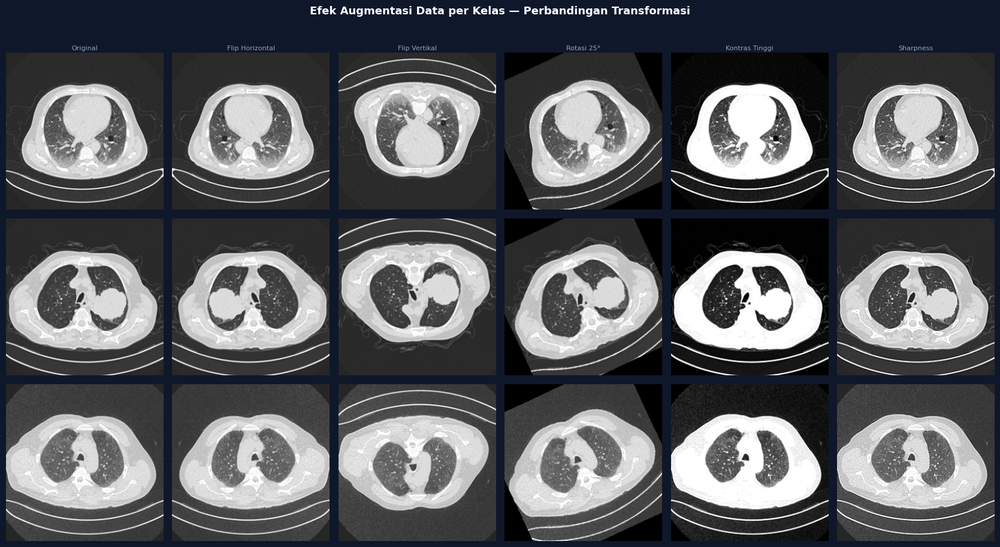

Disimpan: viz_sev_augmentation.png


In [20]:
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import os, random, copy

def apply_transforms(img):
    return [
        ("Original",       img.copy()),
        ("Flip Horizontal",img.transpose(Image.FLIP_LEFT_RIGHT)),
        ("Flip Vertikal",  img.transpose(Image.FLIP_TOP_BOTTOM)),
        ("Rotasi 25°",     img.rotate(25)),
        ("Kontras Tinggi", ImageEnhance.Contrast(img).enhance(1.6)),
        ("Sharpness",      ImageEnhance.Sharpness(img).enhance(2.0)),
    ]

n_cls = len(CLASS_NAMES)
n_aug = 6
cls_colors = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(n_cls, n_aug, figsize=(n_aug * 2.8, n_cls * 3))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Efek Augmentasi Data per Kelas — Perbandingan Transformasi",
             fontsize=13, fontweight="bold", color="white", y=1.02)

for row, (cls, color) in enumerate(zip(CLASS_NAMES, cls_colors)):
    folder = os.path.join(base_dir, cls)
    files  = [f for f in os.listdir(folder)
              if os.path.isfile(os.path.join(folder, f))]
    img_path = os.path.join(folder, random.choice(files))
    img = Image.open(img_path).convert("RGB").resize((256, 256))
    transforms = apply_transforms(img)

    for col, (name, aug_img) in enumerate(transforms):
        ax = axes[row][col]
        ax.imshow(aug_img); ax.axis("off"); ax.set_facecolor("#0f172a")
        if row == 0:
            ax.set_title(name, fontsize=8, color="#94a3b8", pad=3)
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, color=color,
                          fontweight="bold", rotation=90, labelpad=6)

plt.tight_layout()
plt.savefig("viz_sev_augmentation.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_augmentation.png")


# 5. Data Loading
Buat DataLoader terpisah untuk train dan val.

In [21]:
from torchvision import transforms

assert 'TRAIN_DIR' in dir(), "ERROR: Jalankan Cell 3 (Data Splitting) terlebih dahulu!"
assert os.path.isdir(TRAIN_DIR), f"Folder train tidak ada: {TRAIN_DIR}"
assert os.path.isdir(VAL_DIR),   f"Folder val tidak ada: {VAL_DIR}"

IMG_SIZE = (512, 512)   # pastikan konsisten dengan augmentasi

data_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(TRAIN_DIR, transform=data_transforms)
val_dataset   = ImageFolder(VAL_DIR,   transform=data_transforms)

# num_workers=0 aman di Windows; Kaggle/Colab bisa pakai 2
_nw = 0 if os.name == 'nt' else 2

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=_nw, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=_nw, pin_memory=True)

print(f"Train: {len(train_dataset)} gambar | Val: {len(val_dataset)} gambar")
print(f"Class mapping: {train_dataset.class_to_idx}")

Train: 1800 gambar | Val: 221 gambar
Class mapping: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}


# 6. Model Setup
ResNet50 pretrained (ImageNet) — ganti fully-connected layer untuk 3 kelas.

In [22]:
resnet50 = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze semua layer kecuali fc (transfer learning)
for param in resnet50.parameters():
    param.requires_grad = False

# Ganti classifier head
num_ftrs = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 3)
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
resnet50 = resnet50.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 127MB/s] 


Using device: cuda


# 7. Training Setup
Loss, optimizer, dan learning-rate scheduler.

In [23]:
criterion = nn.CrossEntropyLoss()

# Hanya optimasi parameter fc yang tidak di-freeze
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet50.parameters()),
    lr=1e-3
)

# ReduceLROnPlateau — turunkan LR jika val_loss tidak membaik
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

# 8. Training Loop
Early Stopping + Best Checkpoint berdasarkan val_loss terendah.

In [24]:
EPOCHS   = 15
PATIENCE = 5

best_val_loss    = float('inf')
epochs_no_improve = 0

train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []

for epoch in range(EPOCHS):
    # ── Train ────────────────────────────────────────
    resnet50.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet50(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        run_loss    += loss.item()
        _, preds     = torch.max(outputs, 1)
        run_correct += (preds == labels).sum().item()
        run_total   += labels.size(0)

    ep_loss = run_loss / len(train_loader)
    ep_acc  = run_correct / run_total
    train_loss_hist.append(ep_loss)
    train_acc_hist.append(ep_acc)

    # ── Validate ─────────────────────────────────────
    resnet50.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet50(inputs)
            loss    = criterion(outputs, labels)
            v_loss += loss.item()
            _, preds  = torch.max(outputs, 1)
            v_correct += (preds == labels).sum().item()
            v_total   += labels.size(0)

    avg_vl  = v_loss / len(val_loader)
    avg_va  = v_correct / v_total
    val_loss_hist.append(avg_vl)
    val_acc_hist.append(avg_va)

    scheduler.step(avg_vl)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {ep_loss:.4f}  Acc: {ep_acc:.4f} | "
          f"Val Loss: {avg_vl:.4f}  Acc: {avg_va:.4f}")

    # ── Checkpoint & Early Stop ───────────────────────
    if avg_vl < best_val_loss:
        best_val_loss = avg_vl
        epochs_no_improve = 0
        torch.save(resnet50.state_dict(), 'best_resnet50.pth')
        print(f"  >>> checkpoint disimpan (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  --- Tidak ada peningkatan ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping pada epoch {epoch+1}!")
            break

# Load ulang bobot terbaik
print("\nMemuat ulang bobot terbaik...")
resnet50.load_state_dict(torch.load('best_resnet50.pth', map_location=device))
resnet50.eval()
print("Selesai.")

Epoch 01/15 | Train Loss: 0.7580  Acc: 0.6900 | Val Loss: 0.4747  Acc: 0.8643
  >>> checkpoint disimpan (val_loss=0.4747)
Epoch 02/15 | Train Loss: 0.5477  Acc: 0.7783 | Val Loss: 0.3585  Acc: 0.8778
  >>> checkpoint disimpan (val_loss=0.3585)
Epoch 03/15 | Train Loss: 0.5065  Acc: 0.7856 | Val Loss: 0.3179  Acc: 0.8778
  >>> checkpoint disimpan (val_loss=0.3179)
Epoch 04/15 | Train Loss: 0.4620  Acc: 0.8067 | Val Loss: 0.3188  Acc: 0.8869
  --- Tidak ada peningkatan (1/5)
Epoch 05/15 | Train Loss: 0.4336  Acc: 0.8333 | Val Loss: 0.2983  Acc: 0.8914
  >>> checkpoint disimpan (val_loss=0.2983)
Epoch 06/15 | Train Loss: 0.4347  Acc: 0.8211 | Val Loss: 0.2762  Acc: 0.8824
  >>> checkpoint disimpan (val_loss=0.2762)
Epoch 07/15 | Train Loss: 0.4104  Acc: 0.8383 | Val Loss: 0.2829  Acc: 0.9050
  --- Tidak ada peningkatan (1/5)
Epoch 08/15 | Train Loss: 0.3909  Acc: 0.8417 | Val Loss: 0.2912  Acc: 0.9050
  --- Tidak ada peningkatan (2/5)
Epoch 09/15 | Train Loss: 0.3767  Acc: 0.8600 | Val Lo

## Visualisasi 5 — Riwayat Pelatihan Model (Loss & Akurasi)

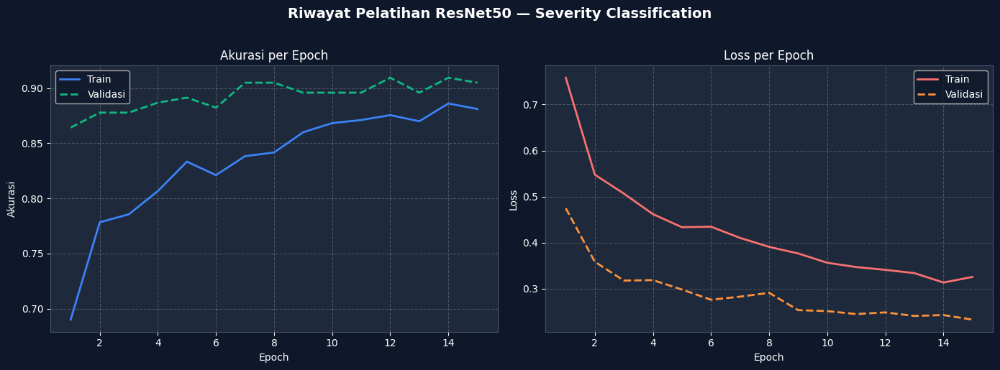

Disimpan: viz_sev_training_history.png


In [25]:
import matplotlib.pyplot as plt

n_ep   = len(train_acc_hist)
epochs = range(1, n_ep + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Riwayat Pelatihan ResNet50 — Severity Classification",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax in axes:
    ax.set_facecolor("#1e293b"); ax.tick_params(colors="white")
    ax.spines[:].set_color("#475569")
    ax.xaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

axes[0].plot(epochs, train_acc_hist, "#3b82f6", linewidth=2, label="Train")
axes[0].plot(epochs, val_acc_hist,   "#10b981", linewidth=2,
             label="Validasi", linestyle="--")
axes[0].set_title("Akurasi per Epoch", color="white", fontsize=12)
axes[0].set_xlabel("Epoch", color="white"); axes[0].set_ylabel("Akurasi", color="white")
axes[0].legend(facecolor="#0f172a", labelcolor="white")

axes[1].plot(epochs, train_loss_hist, "#f87171", linewidth=2, label="Train")
axes[1].plot(epochs, val_loss_hist,   "#fb923c", linewidth=2,
             label="Validasi", linestyle="--")
axes[1].set_title("Loss per Epoch", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white"); axes[1].set_ylabel("Loss", color="white")
axes[1].legend(facecolor="#0f172a", labelcolor="white")

plt.tight_layout()
plt.savefig("viz_sev_training_history.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_training_history.png")


## Visualisasi 5 — Riwayat Pelatihan Model (Loss & Akurasi)

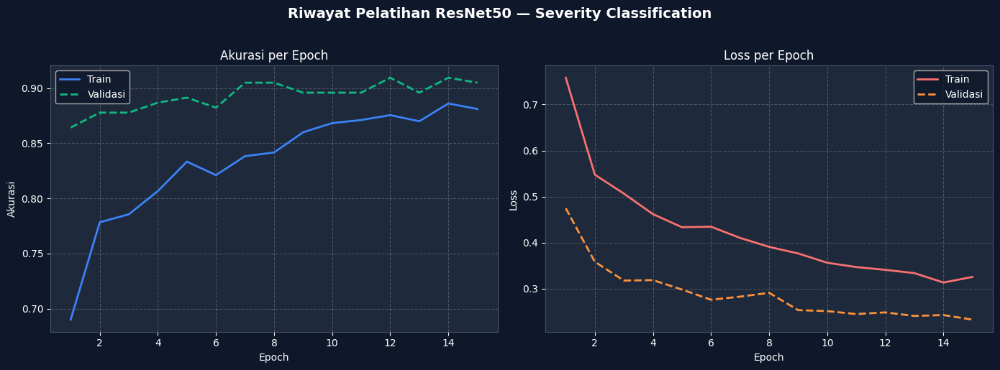

Disimpan: viz_sev_training_history.png


In [26]:
import matplotlib.pyplot as plt

n_ep   = len(train_acc_hist)
epochs = range(1, n_ep + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Riwayat Pelatihan ResNet50 — Severity Classification",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax in axes:
    ax.set_facecolor("#1e293b"); ax.tick_params(colors="white")
    ax.spines[:].set_color("#475569")
    ax.xaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

axes[0].plot(epochs, train_acc_hist, "#3b82f6", linewidth=2, label="Train")
axes[0].plot(epochs, val_acc_hist,   "#10b981", linewidth=2,
             label="Validasi", linestyle="--")
axes[0].set_title("Akurasi per Epoch", color="white", fontsize=12)
axes[0].set_xlabel("Epoch", color="white"); axes[0].set_ylabel("Akurasi", color="white")
axes[0].legend(facecolor="#0f172a", labelcolor="white")

axes[1].plot(epochs, train_loss_hist, "#f87171", linewidth=2, label="Train")
axes[1].plot(epochs, val_loss_hist,   "#fb923c", linewidth=2,
             label="Validasi", linestyle="--")
axes[1].set_title("Loss per Epoch", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white"); axes[1].set_ylabel("Loss", color="white")
axes[1].legend(facecolor="#0f172a", labelcolor="white")

plt.tight_layout()
plt.savefig("viz_sev_training_history.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_training_history.png")


## Visualisasi 5 — Riwayat Pelatihan Model (Loss & Akurasi)

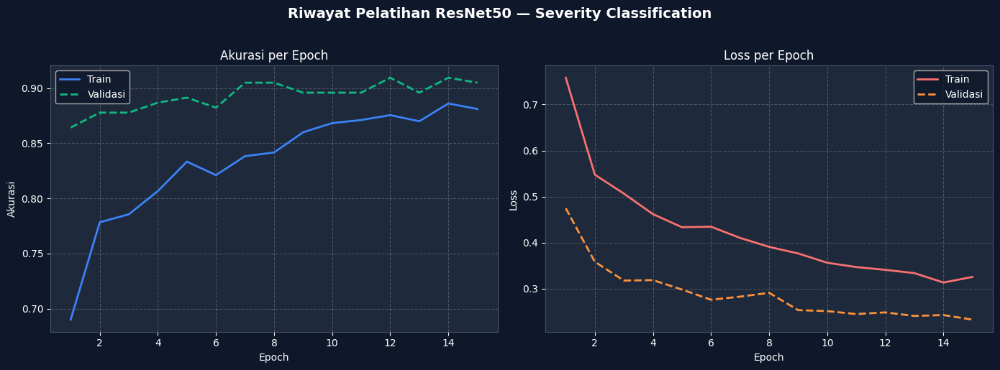

Disimpan: viz_sev_training_history.png


In [27]:
import matplotlib.pyplot as plt

n_ep   = len(train_acc_hist)
epochs = range(1, n_ep + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Riwayat Pelatihan ResNet50 — Severity Classification",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax in axes:
    ax.set_facecolor("#1e293b"); ax.tick_params(colors="white")
    ax.spines[:].set_color("#475569")
    ax.xaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

axes[0].plot(epochs, train_acc_hist, "#3b82f6", linewidth=2, label="Train")
axes[0].plot(epochs, val_acc_hist,   "#10b981", linewidth=2,
             label="Validasi", linestyle="--")
axes[0].set_title("Akurasi per Epoch", color="white", fontsize=12)
axes[0].set_xlabel("Epoch", color="white"); axes[0].set_ylabel("Akurasi", color="white")
axes[0].legend(facecolor="#0f172a", labelcolor="white")

axes[1].plot(epochs, train_loss_hist, "#f87171", linewidth=2, label="Train")
axes[1].plot(epochs, val_loss_hist,   "#fb923c", linewidth=2,
             label="Validasi", linestyle="--")
axes[1].set_title("Loss per Epoch", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white"); axes[1].set_ylabel("Loss", color="white")
axes[1].legend(facecolor="#0f172a", labelcolor="white")

plt.tight_layout()
plt.savefig("viz_sev_training_history.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_training_history.png")


## Visualisasi 5 — Riwayat Pelatihan Model (Loss & Akurasi)

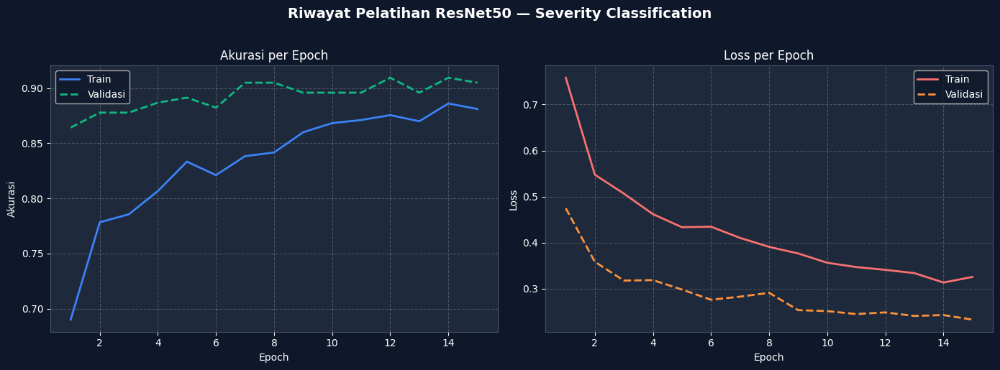

Disimpan: viz_sev_training_history.png


In [28]:
import matplotlib.pyplot as plt

n_ep   = len(train_acc_hist)
epochs = range(1, n_ep + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f172a")
fig.suptitle("Riwayat Pelatihan ResNet50 — Severity Classification",
             fontsize=14, fontweight="bold", color="white", y=1.02)

for ax in axes:
    ax.set_facecolor("#1e293b"); ax.tick_params(colors="white")
    ax.spines[:].set_color("#475569")
    ax.xaxis.grid(True, linestyle="--", alpha=0.2, color="white")
    ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

axes[0].plot(epochs, train_acc_hist, "#3b82f6", linewidth=2, label="Train")
axes[0].plot(epochs, val_acc_hist,   "#10b981", linewidth=2,
             label="Validasi", linestyle="--")
axes[0].set_title("Akurasi per Epoch", color="white", fontsize=12)
axes[0].set_xlabel("Epoch", color="white"); axes[0].set_ylabel("Akurasi", color="white")
axes[0].legend(facecolor="#0f172a", labelcolor="white")

axes[1].plot(epochs, train_loss_hist, "#f87171", linewidth=2, label="Train")
axes[1].plot(epochs, val_loss_hist,   "#fb923c", linewidth=2,
             label="Validasi", linestyle="--")
axes[1].set_title("Loss per Epoch", color="white", fontsize=12)
axes[1].set_xlabel("Epoch", color="white"); axes[1].set_ylabel("Loss", color="white")
axes[1].legend(facecolor="#0f172a", labelcolor="white")

plt.tight_layout()
plt.savefig("viz_sev_training_history.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_training_history.png")


# 9. Evaluasi & Visualisasi
Metrik akhir + plot Loss/Accuracy.

=== Metrik Evaluasi ResNet50 ===
  Accuracy: 0.905
  Precision: 0.9068
  Recall: 0.905
  F1 Score: 0.8925


,Accuracy,Precision,Recall,F1 Score
0,0.905,0.9068,0.905,0.8925


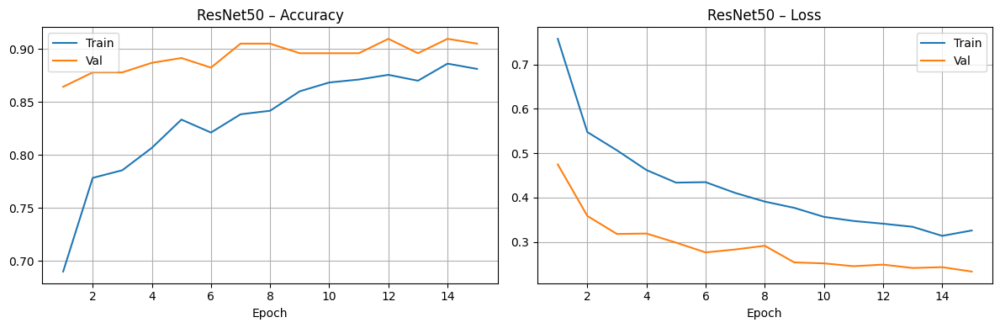

In [29]:
all_preds, all_labels = [], []
n_correct, n_total    = 0, 0

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outs = resnet50(imgs)
        _, preds = torch.max(outs, 1)
        n_correct += (preds == lbls).sum().item()
        n_total   += lbls.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

metrics = {
    'Accuracy' : round(n_correct / n_total, 4),
    'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    'Recall'   : round(recall_score   (y_true, y_pred, average='weighted', zero_division=0), 4),
    'F1 Score' : round(f1_score       (y_true, y_pred, average='weighted', zero_division=0), 4),
}

print("=== Metrik Evaluasi ResNet50 ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

display(pd.DataFrame([metrics]))

# ── Plot ─────────────────────────────────────────────
n_ep = len(train_acc_hist)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, n_ep+1), train_acc_hist, label='Train')
axes[0].plot(range(1, n_ep+1), val_acc_hist,   label='Val')
axes[0].set_title('ResNet50 – Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(range(1, n_ep+1), train_loss_hist, label='Train')
axes[1].plot(range(1, n_ep+1), val_loss_hist,   label='Val')
axes[1].set_title('ResNet50 – Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

## Visualisasi 6 — Kurva ROC, Distribusi Confidence & Metrik per Kelas

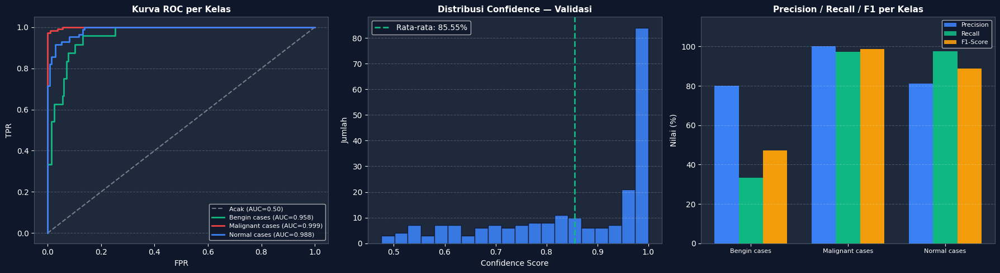

Disimpan: viz_sev_roc_metrics.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

n_cls  = len(CLASS_NAMES)
y_bin  = label_binarize(y_true, classes=list(range(n_cls)))

# Kumpulkan probabilitas
all_probs = []
resnet50.eval()
with torch.no_grad():
    for imgs, _ in val_loader:
        probs = F.softmax(resnet50(imgs.to(device)), dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

colors_roc = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f172a")

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#1e293b"); ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.plot([0,1],[0,1],"w--", alpha=0.4, label="Acak (AUC=0.50)")
for i, (cls, c) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.set_title("Kurva ROC per Kelas", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("FPR", color="white"); ax.set_ylabel("TPR", color="white")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=8, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Confidence ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b"); ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
conf = np.max(all_probs, axis=1)
ax2.hist(conf, bins=20, color="#3b82f6", edgecolor="#0f172a", alpha=0.9)
ax2.axvline(conf.mean(), color="#10b981", linewidth=2, linestyle="--",
            label=f"Rata-rata: {conf.mean():.2%}")
ax2.set_title("Distribusi Confidence — Validasi", color="white", fontsize=11, fontweight="bold")
ax2.set_xlabel("Confidence Score", color="white"); ax2.set_ylabel("Jumlah", color="white")
ax2.legend(facecolor="#0f172a", labelcolor="white")
ax2.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Per-class bar ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b"); ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
x = np.arange(n_cls); w = 0.25
prec = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec  = recall_score   (y_true, y_pred, average=None, zero_division=0) * 100
f1   = f1_score       (y_true, y_pred, average=None, zero_division=0) * 100
for bars, vals, label, color in [
    (ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9), prec, "Precision", "#3b82f6"),
    (ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9), rec,  "Recall",    "#10b981"),
    (ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9), f1,   "F1",        "#f59e0b"),
]:
    pass
ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9, label="Precision")
ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9, label="Recall")
ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9, label="F1-Score")
ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, color="white", fontsize=8)
ax3.set_ylim(0, 115)
ax3.set_title("Precision / Recall / F1 per Kelas", color="white", fontsize=11, fontweight="bold")
ax3.set_ylabel("Nilai (%)", color="white")
ax3.legend(facecolor="#0f172a", labelcolor="white", fontsize=8)
ax3.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig("viz_sev_roc_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_roc_metrics.png")


## Visualisasi 6 — Kurva ROC, Distribusi Confidence & Metrik per Kelas

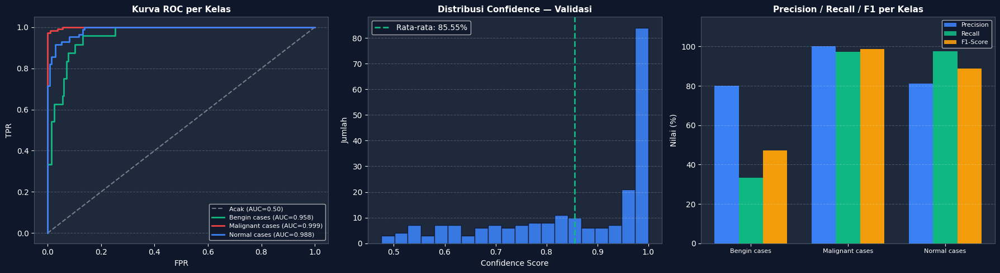

Disimpan: viz_sev_roc_metrics.png


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

n_cls  = len(CLASS_NAMES)
y_bin  = label_binarize(y_true, classes=list(range(n_cls)))

# Kumpulkan probabilitas
all_probs = []
resnet50.eval()
with torch.no_grad():
    for imgs, _ in val_loader:
        probs = F.softmax(resnet50(imgs.to(device)), dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

colors_roc = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f172a")

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#1e293b"); ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.plot([0,1],[0,1],"w--", alpha=0.4, label="Acak (AUC=0.50)")
for i, (cls, c) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.set_title("Kurva ROC per Kelas", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("FPR", color="white"); ax.set_ylabel("TPR", color="white")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=8, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Confidence ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b"); ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
conf = np.max(all_probs, axis=1)
ax2.hist(conf, bins=20, color="#3b82f6", edgecolor="#0f172a", alpha=0.9)
ax2.axvline(conf.mean(), color="#10b981", linewidth=2, linestyle="--",
            label=f"Rata-rata: {conf.mean():.2%}")
ax2.set_title("Distribusi Confidence — Validasi", color="white", fontsize=11, fontweight="bold")
ax2.set_xlabel("Confidence Score", color="white"); ax2.set_ylabel("Jumlah", color="white")
ax2.legend(facecolor="#0f172a", labelcolor="white")
ax2.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Per-class bar ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b"); ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
x = np.arange(n_cls); w = 0.25
prec = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec  = recall_score   (y_true, y_pred, average=None, zero_division=0) * 100
f1   = f1_score       (y_true, y_pred, average=None, zero_division=0) * 100
for bars, vals, label, color in [
    (ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9), prec, "Precision", "#3b82f6"),
    (ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9), rec,  "Recall",    "#10b981"),
    (ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9), f1,   "F1",        "#f59e0b"),
]:
    pass
ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9, label="Precision")
ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9, label="Recall")
ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9, label="F1-Score")
ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, color="white", fontsize=8)
ax3.set_ylim(0, 115)
ax3.set_title("Precision / Recall / F1 per Kelas", color="white", fontsize=11, fontweight="bold")
ax3.set_ylabel("Nilai (%)", color="white")
ax3.legend(facecolor="#0f172a", labelcolor="white", fontsize=8)
ax3.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig("viz_sev_roc_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_roc_metrics.png")


## Visualisasi 6 — Kurva ROC, Distribusi Confidence & Metrik per Kelas

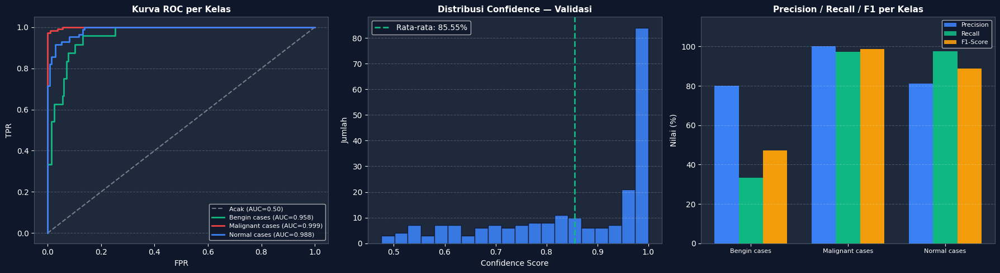

Disimpan: viz_sev_roc_metrics.png


In [32]:
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

n_cls  = len(CLASS_NAMES)
y_bin  = label_binarize(y_true, classes=list(range(n_cls)))

# Kumpulkan probabilitas
all_probs = []
resnet50.eval()
with torch.no_grad():
    for imgs, _ in val_loader:
        probs = F.softmax(resnet50(imgs.to(device)), dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

colors_roc = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f172a")

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#1e293b"); ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.plot([0,1],[0,1],"w--", alpha=0.4, label="Acak (AUC=0.50)")
for i, (cls, c) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.set_title("Kurva ROC per Kelas", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("FPR", color="white"); ax.set_ylabel("TPR", color="white")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=8, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Confidence ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b"); ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
conf = np.max(all_probs, axis=1)
ax2.hist(conf, bins=20, color="#3b82f6", edgecolor="#0f172a", alpha=0.9)
ax2.axvline(conf.mean(), color="#10b981", linewidth=2, linestyle="--",
            label=f"Rata-rata: {conf.mean():.2%}")
ax2.set_title("Distribusi Confidence — Validasi", color="white", fontsize=11, fontweight="bold")
ax2.set_xlabel("Confidence Score", color="white"); ax2.set_ylabel("Jumlah", color="white")
ax2.legend(facecolor="#0f172a", labelcolor="white")
ax2.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Per-class bar ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b"); ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
x = np.arange(n_cls); w = 0.25
prec = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec  = recall_score   (y_true, y_pred, average=None, zero_division=0) * 100
f1   = f1_score       (y_true, y_pred, average=None, zero_division=0) * 100
for bars, vals, label, color in [
    (ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9), prec, "Precision", "#3b82f6"),
    (ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9), rec,  "Recall",    "#10b981"),
    (ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9), f1,   "F1",        "#f59e0b"),
]:
    pass
ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9, label="Precision")
ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9, label="Recall")
ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9, label="F1-Score")
ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, color="white", fontsize=8)
ax3.set_ylim(0, 115)
ax3.set_title("Precision / Recall / F1 per Kelas", color="white", fontsize=11, fontweight="bold")
ax3.set_ylabel("Nilai (%)", color="white")
ax3.legend(facecolor="#0f172a", labelcolor="white", fontsize=8)
ax3.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig("viz_sev_roc_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_roc_metrics.png")


## Visualisasi 6 — Kurva ROC, Distribusi Confidence & Metrik per Kelas

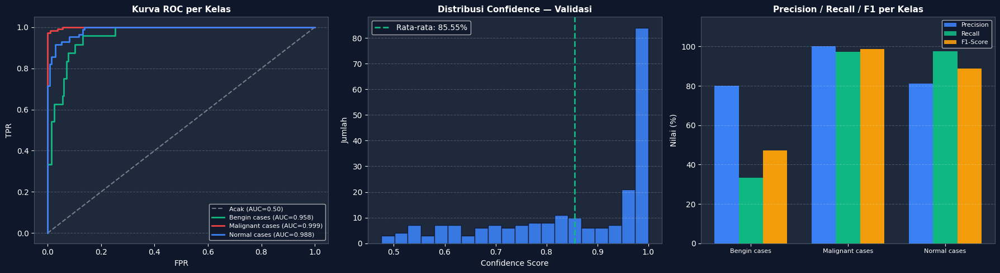

Disimpan: viz_sev_roc_metrics.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize

n_cls  = len(CLASS_NAMES)
y_bin  = label_binarize(y_true, classes=list(range(n_cls)))

# Kumpulkan probabilitas
all_probs = []
resnet50.eval()
with torch.no_grad():
    for imgs, _ in val_loader:
        probs = F.softmax(resnet50(imgs.to(device)), dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

colors_roc = ["#10b981", "#ef4444", "#3b82f6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f172a")

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#1e293b"); ax.tick_params(colors="white"); ax.spines[:].set_color("#475569")
ax.plot([0,1],[0,1],"w--", alpha=0.4, label="Acak (AUC=0.50)")
for i, (cls, c) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, color=c, linewidth=2, label=f"{cls} (AUC={auc(fpr,tpr):.3f})")
ax.set_title("Kurva ROC per Kelas", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("FPR", color="white"); ax.set_ylabel("TPR", color="white")
ax.legend(facecolor="#0f172a", labelcolor="white", fontsize=8, loc="lower right")
ax.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Confidence ───────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#1e293b"); ax2.tick_params(colors="white"); ax2.spines[:].set_color("#475569")
conf = np.max(all_probs, axis=1)
ax2.hist(conf, bins=20, color="#3b82f6", edgecolor="#0f172a", alpha=0.9)
ax2.axvline(conf.mean(), color="#10b981", linewidth=2, linestyle="--",
            label=f"Rata-rata: {conf.mean():.2%}")
ax2.set_title("Distribusi Confidence — Validasi", color="white", fontsize=11, fontweight="bold")
ax2.set_xlabel("Confidence Score", color="white"); ax2.set_ylabel("Jumlah", color="white")
ax2.legend(facecolor="#0f172a", labelcolor="white")
ax2.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

# ── Per-class bar ─────────────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#1e293b"); ax3.tick_params(colors="white"); ax3.spines[:].set_color("#475569")
x = np.arange(n_cls); w = 0.25
prec = precision_score(y_true, y_pred, average=None, zero_division=0) * 100
rec  = recall_score   (y_true, y_pred, average=None, zero_division=0) * 100
f1   = f1_score       (y_true, y_pred, average=None, zero_division=0) * 100
for bars, vals, label, color in [
    (ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9), prec, "Precision", "#3b82f6"),
    (ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9), rec,  "Recall",    "#10b981"),
    (ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9), f1,   "F1",        "#f59e0b"),
]:
    pass
ax3.bar(x-w, prec, w, color="#3b82f6", alpha=0.9, label="Precision")
ax3.bar(x,   rec,  w, color="#10b981", alpha=0.9, label="Recall")
ax3.bar(x+w, f1,   w, color="#f59e0b", alpha=0.9, label="F1-Score")
ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, color="white", fontsize=8)
ax3.set_ylim(0, 115)
ax3.set_title("Precision / Recall / F1 per Kelas", color="white", fontsize=11, fontweight="bold")
ax3.set_ylabel("Nilai (%)", color="white")
ax3.legend(facecolor="#0f172a", labelcolor="white", fontsize=8)
ax3.yaxis.grid(True, linestyle="--", alpha=0.2, color="white")

plt.tight_layout()
plt.savefig("viz_sev_roc_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
plt.show()
print("Disimpan: viz_sev_roc_metrics.png")


# 10. Classification Report, Confusion Matrix & Confidence

=== Detailed Classification Report ===
                 precision    recall  f1-score   support

   Bengin cases       0.80      0.33      0.47        24
Malignant cases       1.00      0.97      0.99       113
   Normal cases       0.81      0.98      0.89        84

       accuracy                           0.90       221
      macro avg       0.87      0.76      0.78       221
   weighted avg       0.91      0.90      0.89       221



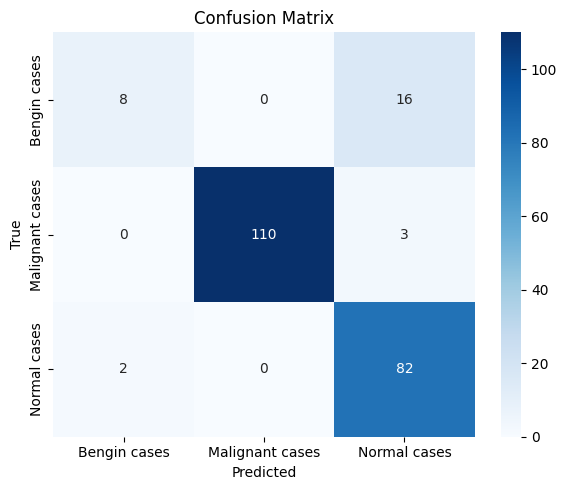


Confidence Statistics:
  Rata-rata : 85.55%
  Max       : 99.99%
  Min       : 47.49%


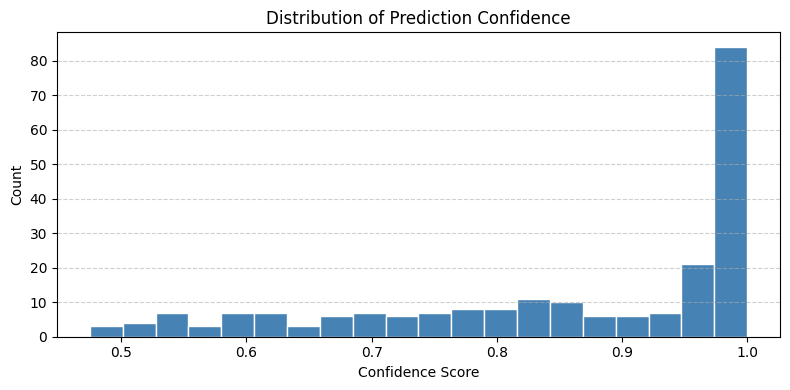

In [34]:
# Classification Report
print("=== Detailed Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# Confidence distribution
all_conf = []
with torch.no_grad():
    for imgs, _ in val_loader:
        imgs  = imgs.to(device)
        probs = F.softmax(resnet50(imgs), dim=1)
        conf, _ = torch.max(probs, dim=1)
        all_conf.extend(conf.cpu().numpy())

all_conf = np.array(all_conf)
print(f"\nConfidence Statistics:")
print(f"  Rata-rata : {all_conf.mean():.2%}")
print(f"  Max       : {all_conf.max():.2%}")
print(f"  Min       : {all_conf.min():.2%}")

plt.figure(figsize=(8, 4))
plt.hist(all_conf, bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Prediction Confidence')
plt.xlabel('Confidence Score'); plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

/tmp/ipykernel_58/3845154536.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3845154536.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3845154536.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("viz_sampel_prediksi_severity.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
/tmp/ipykernel_58/3845154536.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("viz_sampel_prediksi_severity.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

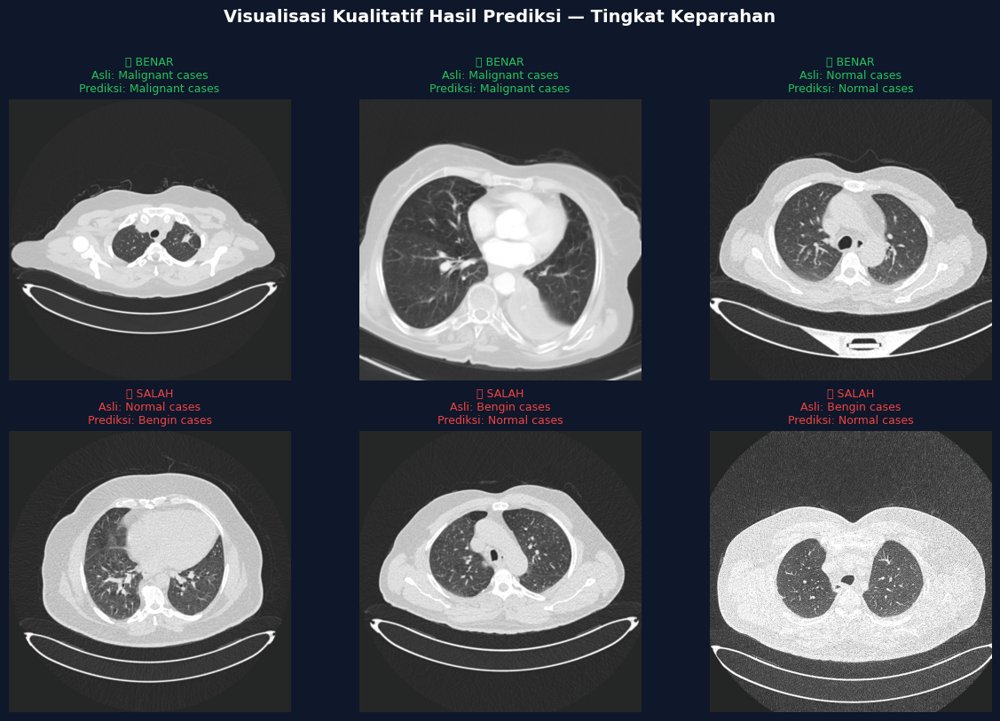

Disimpan: viz_sampel_prediksi_severity.png


In [35]:
"""## Visualisasi — Sampel Prediksi Benar & Salah (Val Set)"""

import matplotlib.pyplot as plt
import numpy as np
import torch

def tampilkan_sampel_prediksi_sev(loader, model, class_names, device, num_samples=3):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    all_imgs, all_true, all_pred = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            outs = model(imgs.to(device))
            _, preds = torch.max(outs, 1)
            all_imgs.extend(imgs.cpu())
            all_true.extend(lbls.numpy())
            all_pred.extend(preds.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    benar_idx = np.where(all_true == all_pred)[0]
    salah_idx = np.where(all_true != all_pred)[0]

    sampel_benar = np.random.choice(benar_idx, min(num_samples, len(benar_idx)), replace=False)
    sampel_salah = np.random.choice(salah_idx, min(num_samples, len(salah_idx)), replace=False)

    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 4, 8))
    fig.patch.set_facecolor("#0f172a")
    fig.suptitle("Visualisasi Kualitatif Hasil Prediksi — Tingkat Keparahan",
                 fontsize=14, fontweight="bold", color="white", y=1.01)

    for i, idx in enumerate(sampel_benar):
        img = (all_imgs[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax = axes[0, i]
        ax.imshow(img); ax.axis("off")
        ax.set_facecolor("#0f172a")
        ax.set_title(f"✅ BENAR\nAsli: {class_names[all_true[idx]]}\nPrediksi: {class_names[all_pred[idx]]}",
                     color="#22c55e", fontsize=9)

    for i, idx in enumerate(sampel_salah):
        img = (all_imgs[idx] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax = axes[1, i]
        ax.imshow(img); ax.axis("off")
        ax.set_facecolor("#0f172a")
        ax.set_title(f"❌ SALAH\nAsli: {class_names[all_true[idx]]}\nPrediksi: {class_names[all_pred[idx]]}",
                     color="#ef4444", fontsize=9)

    plt.tight_layout()
    plt.savefig("viz_sampel_prediksi_severity.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
    plt.show()
    print("Disimpan: viz_sampel_prediksi_severity.png")

# Jalankan — CLASS_NAMES & val_loader sudah ada dari cell sebelumnya
# Label dari ImageFolder urut alfabetis: ['Bengin cases', 'Malignant cases', 'Normal cases']
label_names = [k for k, v in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])]
tampilkan_sampel_prediksi_sev(val_loader, resnet50, label_names, device, num_samples=3)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


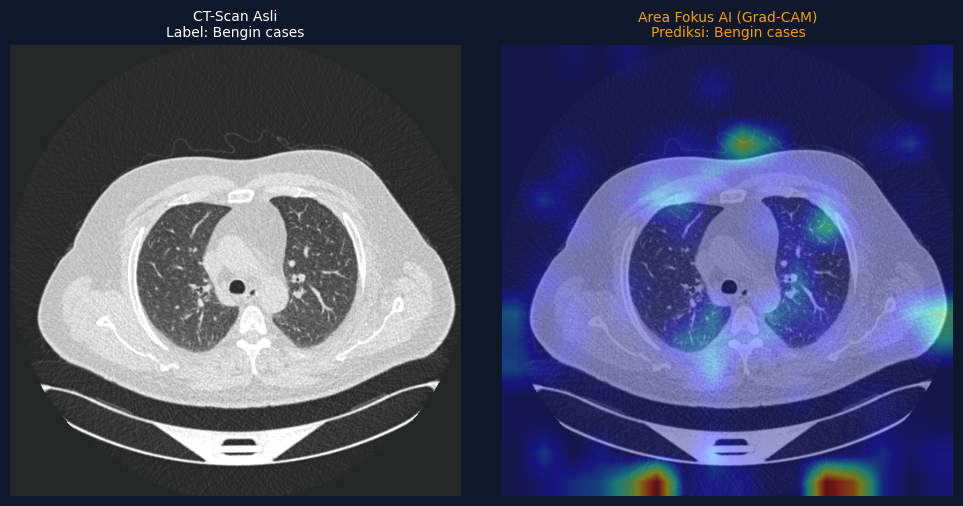

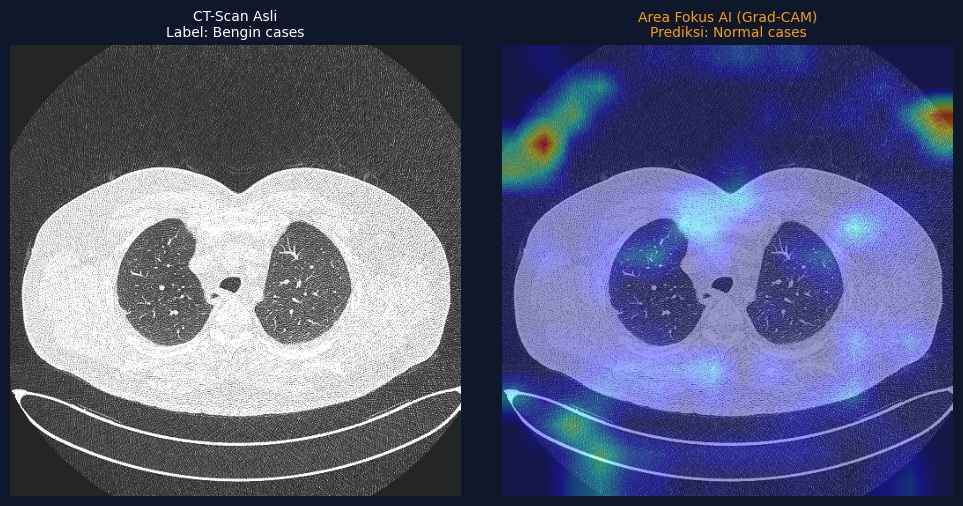

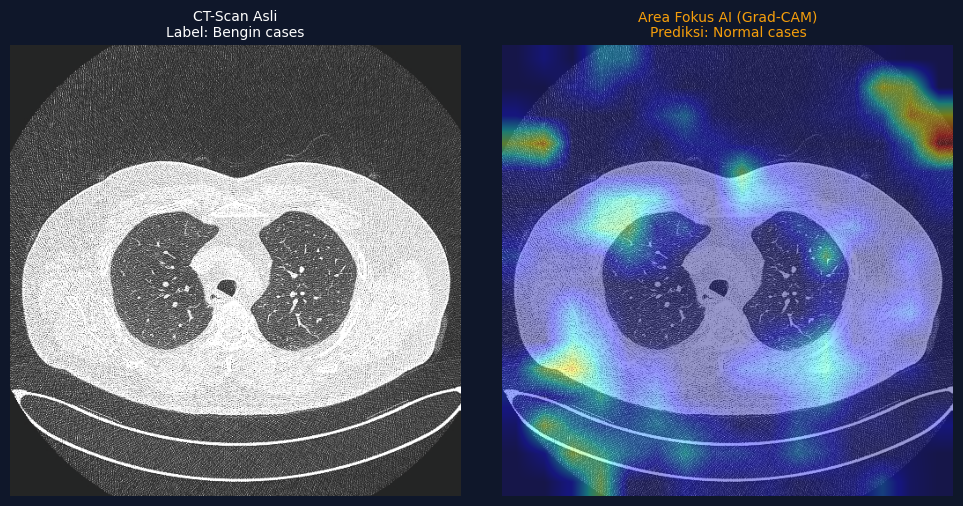

In [36]:
"""## Grad-CAM — Tingkat Keparahan"""

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

_grads_s, _acts_s = {}, {}

def hook_grad_s(m, gi, go):  _grads_s['l4'] = go[0]
def hook_act_s(m, i, o):     _acts_s['l4']  = o

h1 = resnet50.layer4[-1].register_forward_hook(hook_act_s)
h2 = resnet50.layer4[-1].register_backward_hook(hook_grad_s)

def buat_heatmap_gradcam_sev(img_tensor, model, pred_index=None):
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)
    x.requires_grad_(True)
    out = model(x)
    if pred_index is None:
        pred_index = out.argmax(dim=1).item()
    model.zero_grad()
    out[0, pred_index].backward()
    weights = _grads_s['l4'].mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * _acts_s['l4']).sum(dim=1)).squeeze()
    cam = cam.detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, pred_index

def tampilkan_gradcam_sev(img_tensor, cam, true_label, pred_label, alpha=0.4):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = (img_tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()

    cam_r   = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = plt.cm.jet(cam_r)[:, :, :3]
    overlay = (alpha * heatmap + (1 - alpha) * img).clip(0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.patch.set_facecolor("#0f172a")
    axes[0].imshow(img);     axes[0].axis("off")
    axes[1].imshow(overlay); axes[1].axis("off")
    axes[0].set_title(f"CT-Scan Asli\nLabel: {true_label}",  color="white", fontsize=10)
    axes[1].set_title(f"Area Fokus AI (Grad-CAM)\nPrediksi: {pred_label}", color="#f59e0b", fontsize=10)
    plt.tight_layout()
    plt.savefig("viz_gradcam_severity.png", dpi=150, bbox_inches="tight", facecolor="#0f172a")
    plt.show()

# Eksekusi — ambil beberapa sampel dari val_loader
label_names = [k for k, v in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])]
sample_imgs, sample_lbls = next(iter(val_loader))
for i in range(min(3, len(sample_imgs))):
    cam, pred_idx = buat_heatmap_gradcam_sev(sample_imgs[i], resnet50)
    tampilkan_gradcam_sev(
        sample_imgs[i],
        cam,
        true_label  = label_names[sample_lbls[i].item()],
        pred_label  = label_names[pred_idx]
    )

h1.remove(); h2.remove()  # bersihkan hooks


# 11. Save Model
Simpan state-dict (`.pth`), TorchScript (`.pt`), dan ONNX (`.onnx`).

In [37]:
# State-dict (bobot terbaik sudah di-load di Cell 8)
shutil.copy('best_resnet50.pth', 'lung-cancer-severity.pth')
print("Disimpan: lung-cancer-severity.pth")

# TorchScript
example = torch.rand(1, 3, 512, 512).to(device)
script  = torch.jit.trace(resnet50, example)
script.save('lung_cancer_model_production.pt')
print("Disimpan: lung_cancer_model_production.pt")

# ONNX
torch.onnx.export(
    resnet50, example, 'lung_cancer_model.onnx',
    export_params=True, opset_version=18,
    do_constant_folding=True,
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Disimpan: lung_cancer_model.onnx")

Disimpan: lung-cancer-severity.pth
Disimpan: lung_cancer_model_production.pt


ModuleNotFoundError: No module named 'onnxscript'